# EDA: df_video Analysis
Data cleaning, exploration, and visualization of raw video data

## 1. Load & Setup

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df_video = pd.read_csv(r"D:\KLTN\analysis\data\final_dataset.csv")
pd.set_option('display.max_columns', None)
print(f"Data shape: {df_video.shape}")
df_video.head()

Data shape: (1180606, 39)


,video_id,views,likes,comments,snapshot_time,is_trending,channel_id,time_id,source,title,description,publish_time,thumbnail,keyword,topic,duration_seconds,definition,caption,licensed_content,category_id,default_language,default_audio_language,tags,channel_title,custom_url,channel_description,published_at,country,subscriber_count,view_count,video_count,date,year,quarter,month,week_of_year,day,weekday,hour
0,atJwRQ1zdjQ,350781,35288,2980,2026-05-13 06:46:25.134504+00:00,1,UCUs8sGiP4avNaYNVO22INhQ,2026051216,trending,mgk & Wiz Khalifa - girl next door (Official M...,Watch the official music video for mgk & @wizk...,2026-05-12 16:00:06+00:00,https://i.ytimg.com/vi/atJwRQ1zdjQ/default.jpg,trending,music,237.0,hd,False,False,10.0,en,NaN,"mgk,wiz khalifa,girl next door,blog era boyz,b...",mgk,@mgk,NaN,2006-12-27T05:10:50Z,US,9470000.0,6.778468e+09,390.0,2026-05-12,2026,2,5,20,12,1,16
1,CnmcXIdMZ2Q,3244,54,4,2026-05-13 06:46:25.134504+00:00,0,UC-ik3qPQU2SQyzzAY5f_v7g,2026051301,search,"GILA! Veda Ega Pratama Bikin Dunia Shock, Indo...",Veda Ega Pratama kembali bikin dunia balap geg...,2026-05-13 01:19:00+00:00,https://i.ytimg.com/vi/CnmcXIdMZ2Q/default.jpg,motogp highlights,sports,29.0,hd,False,False,17.0,id,id,"veda ega pratama,\nveda ega moto3,\nmoto3 2026...",GLORA MOTOR,@gloramotor-k3,selamat datang di channel yang membahas panasn...,2025-11-15T14:50:48.636622Z,NaN,1130.0,1.262324e+06,134.0,2026-05-13,2026,2,5,20,13,2,1
2,fNEGWXFmZcU,1709706,38087,1247,2026-05-13 06:46:25.134504+00:00,0,UCB_qr75-ydFVKSF9Dmo6izg,2026031306,search,FP1 Highlights | 2026 Chinese Grand Prix,Catch up on all the highlights from the sole p...,2026-03-13 06:01:00+00:00,https://i.ytimg.com/vi/fNEGWXFmZcU/default.jpg,formula 1 highlights,sports,300.0,hd,False,True,17.0,en,en,"F1,Formula One,Formula 1,Sports,Sport,Action,G...",FORMULA 1,@formula1,2026 - It's All To Drive For\n,2005-12-29T00:34:38Z,NaN,14600000.0,9.663627e+09,10069.0,2026-03-13,2026,1,3,11,13,4,6
3,jL56ArZGc14,902,8,0,2026-05-13 06:46:25.134504+00:00,0,UChJQ9QWkZX28Rb8UwbD3vqg,2026031408,search,2026 China Grand Prix I Sprint Race Highlights...,Sprint Highlights | 2026 Chinese Grand Prix Ke...,2026-03-14 08:47:57+00:00,https://i.ytimg.com/vi/jL56ArZGc14/default.jpg,formula 1 highlights,sports,35.0,hd,False,False,2.0,en,NaN,"#f1,#formula1,#f1sprint",MotoGenic,@motogenicrr,I created this channel to upload good quality ...,2011-10-12T07:38:31Z,NaN,161.0,1.663070e+05,133.0,2026-03-14,2026,1,3,11,14,5,8
4,ENqY3GeF1TM,11890,314,2,2026-05-13 06:46:25.134504+00:00,0,UCGtU-xV4vCM9bFoOwI16q9A,2026031409,search,Alonso 2026 highlights - F1 2026 | #f1 #alonso...,charlesleclerc #maxverstappen #alonso #lewisha...,2026-03-14 09:00:29+00:00,https://i.ytimg.com/vi/ENqY3GeF1TM/default.jpg,formula 1 highlights,sports,11.0,hd,False,False,17.0,it,en-US,NaN,Daliots Sport,@liotts-sport,🏎️⚽ Benvenuti nel canale sport di Daliots!\n\n...,2024-12-21T15:54:51.992711Z,IT,1580.0,3.197998e+06,69.0,2026-03-14,2026,1,3,11,14,5,9


In [2]:
df_video.rename(columns={"published_at": "channel_created_at"}, inplace=True)

In [3]:
df_video.isnull().sum()

video_id                       0
views                          0
likes                          0
comments                       0
snapshot_time                  0
is_trending                    0
channel_id                     0
time_id                        0
source                         0
title                          0
description               239609
publish_time                   0
thumbnail                      0
keyword                        0
topic                          0
duration_seconds               0
definition                     0
caption                        0
licensed_content               0
category_id                    0
default_language              11
default_audio_language    239212
tags                      482363
channel_title               4347
custom_url                 26925
channel_description       117854
channel_created_at          4347
country                   326741
subscriber_count            4347
view_count                  4347
video_coun

## 2. Data Processing & Type Conversion

In [4]:
df_video["snapshot_time"] = pd.to_datetime(df_video["snapshot_time"], errors="coerce")
df_video["publish_time"] = pd.to_datetime(df_video["publish_time"], errors="coerce")
df_video["date"] = pd.to_datetime(df_video["date"], errors="coerce")
df_video["is_trending"] = df_video["is_trending"].astype(bool)
df_video["duration_seconds"] = df_video["duration_seconds"].astype("Int64")
df_video["category_id"] = df_video["category_id"].astype("Int64")
df_video["subscriber_count"] = df_video["subscriber_count"].astype("Int64")
df_video["view_count"] = df_video["view_count"].astype("Int64")
df_video["video_count"] = df_video["video_count"].astype("Int64")
df_video.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1180606 entries, 0 to 1180605
Data columns (total 39 columns):
 #   Column                  Non-Null Count    Dtype              
---  ------                  --------------    -----              
 0   video_id                1180606 non-null  object             
 1   views                   1180606 non-null  int64              
 2   likes                   1180606 non-null  int64              
 3   comments                1180606 non-null  int64              
 4   snapshot_time           1180606 non-null  datetime64[ns, UTC]
 5   is_trending             1180606 non-null  bool               
 6   channel_id              1180606 non-null  object             
 7   time_id                 1180606 non-null  int64              
 8   source                  1180606 non-null  object             
 9   title                   1180606 non-null  object             
 10  description             940997 non-null   object             
 11  publish_tim

## 3. Handle Missing Values

In [5]:
print("Missing values before:")
print(df_video.isnull().sum())

Missing values before:
video_id                       0
views                          0
likes                          0
comments                       0
snapshot_time                  0
is_trending                    0
channel_id                     0
time_id                        0
source                         0
title                          0
description               239609
publish_time                   0
thumbnail                      0
keyword                        0
topic                          0
duration_seconds               0
definition                     0
caption                        0
licensed_content               0
category_id                    0
default_language              11
default_audio_language    239212
tags                      482363
channel_title               4347
custom_url                 26925
channel_description       117854
channel_created_at          4347
country                   326741
subscriber_count            4347
view_count          

In [6]:
df_video["description"] = df_video["description"].fillna("Unknown")
df_video["tags"] = df_video["tags"].fillna("Unknown")
df_video["default_language"] = df_video["default_language"].fillna("Unknown")
df_video["default_audio_language"] = df_video["default_audio_language"].fillna("Unknown")
df_video["channel_title"] = df_video["channel_title"].fillna("Unknown")
df_video["custom_url"] = df_video["custom_url"].fillna("Unknown")
df_video["channel_description"] = df_video["channel_description"].fillna("Unknown")
df_video["country"] = df_video["country"].fillna("Unknown")

df_video = df_video.dropna(subset=["video_count", "view_count"])
print("Null values after handling:")
print(df_video.isnull().sum())

Null values after handling:
video_id                  0
views                     0
likes                     0
comments                  0
snapshot_time             0
is_trending               0
channel_id                0
time_id                   0
source                    0
title                     0
description               0
publish_time              0
thumbnail                 0
keyword                   0
topic                     0
duration_seconds          0
definition                0
caption                   0
licensed_content          0
category_id               0
default_language          0
default_audio_language    0
tags                      0
channel_title             0
custom_url                0
channel_description       0
channel_created_at        0
country                   0
subscriber_count          0
view_count                0
video_count               0
date                      0
year                      0
quarter                   0
month               

## 4. Map Country to Region

In [7]:
country_to_region = {
    # North America
    "US": "North America", "CA": "North America", "MX": "North America",
    "GT": "North America", "CU": "North America", "DO": "North America",
    "PR": "North America", "HN": "North America", "SV": "North America",
    "NI": "North America", "CR": "North America", "PA": "North America",
    "JM": "North America", "GL": "North America", "AG": "North America",
    "AI": "North America", "VG": "North America",

    # South America
    "BR": "South America", "AR": "South America", "CL": "South America",
    "CO": "South America", "PE": "South America", "VE": "South America",
    "EC": "South America", "BO": "South America", "PY": "South America",
    "UY": "South America",

    # Western Europe
    "GB": "Western Europe", "FR": "Western Europe", "DE": "Western Europe",
    "IT": "Western Europe", "ES": "Western Europe", "NL": "Western Europe",
    "PT": "Western Europe", "IE": "Western Europe", "AT": "Western Europe",
    "BE": "Western Europe", "CH": "Western Europe", "LU": "Western Europe",
    "GI": "Western Europe",

    # Northern Europe
    "SE": "Northern Europe", "NO": "Northern Europe", "DK": "Northern Europe",
    "FI": "Northern Europe", "IS": "Northern Europe",

    # Eastern Europe
    "PL": "Eastern Europe", "RO": "Eastern Europe", "HU": "Eastern Europe",
    "CZ": "Eastern Europe", "SK": "Eastern Europe", "BG": "Eastern Europe",
    "HR": "Eastern Europe", "RS": "Eastern Europe", "UA": "Eastern Europe",
    "RU": "Eastern Europe", "BY": "Eastern Europe", "MD": "Eastern Europe",
    "SI": "Eastern Europe", "BA": "Eastern Europe", "MK": "Eastern Europe",
    "AL": "Eastern Europe", "ME": "Eastern Europe", "LT": "Eastern Europe",
    "LV": "Eastern Europe", "EE": "Eastern Europe",

    # Southern Europe
    "GR": "Southern Europe", "CY": "Southern Europe", "MT": "Southern Europe",

    # Southeast Asia
    "VN": "Southeast Asia", "ID": "Southeast Asia", "TH": "Southeast Asia",
    "PH": "Southeast Asia", "MY": "Southeast Asia", "SG": "Southeast Asia",
    "KH": "Southeast Asia", "LA": "Southeast Asia", "MM": "Southeast Asia",

    # East Asia
    "JP": "East Asia", "KR": "East Asia", "CN": "East Asia",
    "TW": "East Asia", "HK": "East Asia", "MN": "East Asia",

    # South Asia
    "IN": "South Asia", "PK": "South Asia", "BD": "South Asia",
    "LK": "South Asia", "NP": "South Asia",

    # Central Asia
    "KZ": "Central Asia", "UZ": "Central Asia", "AZ": "Central Asia",
    "GE": "Central Asia", "AM": "Central Asia", "AF": "Central Asia",

    # Middle East
    "AE": "Middle East", "SA": "Middle East", "IL": "Middle East",
    "TR": "Middle East", "EG": "Middle East", "JO": "Middle East",
    "LB": "Middle East", "KW": "Middle East", "QA": "Middle East",
    "BH": "Middle East", "OM": "Middle East", "YE": "Middle East",
    "IQ": "Middle East", "IR": "Middle East",

    # Africa
    "ZA": "Africa", "NG": "Africa", "KE": "Africa", "MA": "Africa",
    "GH": "Africa", "CM": "Africa", "TZ": "Africa", "ET": "Africa",
    "SN": "Africa", "CI": "Africa", "TN": "Africa", "DZ": "Africa",
    "LY": "Africa", "UG": "Africa", "ZW": "Africa", "MZ": "Africa",
    "AO": "Africa",

    # Oceania
    "AU": "Oceania", "NZ": "Oceania", "PG": "Oceania",
    "NF": "Oceania", "WF": "Oceania", "GS": "Oceania",
    "AQ": "Oceania", "IO": "Oceania",
}

In [8]:
LANG_TO_REGION = {
    # Southeast Asia
    "vi": "Southeast Asia", "id": "Southeast Asia", "th": "Southeast Asia",
    "fil": "Southeast Asia", "ms": "Southeast Asia", "km": "Southeast Asia",

    # East Asia
    "ko": "East Asia", "ja": "East Asia", "zh-Hant": "East Asia",

    # South Asia
    "hi": "South Asia", "bn": "South Asia", "en-IN": "South Asia",
    "ta": "South Asia", "te": "South Asia", "ml": "South Asia", "ur": "South Asia",

    # Middle East
    "ar": "Middle East", "iw": "Middle East", "tr": "Middle East",

    # Eastern Europe
    "ru": "Eastern Europe", "uk": "Eastern Europe", "pl": "Eastern Europe",
    "ro": "Eastern Europe", "hu": "Eastern Europe",

    # Western Europe
    "de": "Western Europe", "fr": "Western Europe", "it": "Western Europe",
    "nl": "Western Europe", "en-GB": "Western Europe",

    # North America
    "en-US": "North America",

    # South America
    "pt-PT": "South America",
}

AUDIO_EXTRA_MAP = {
    **LANG_TO_REGION,
    "en-US": "North America",
    "en-GB": "Western Europe",
    "en-IN": "South Asia",
    "pa": "South Asia",
}

nan_mask = df_video["country"] == "Unknown"

# Infer from default_language
inferred_region = df_video.loc[nan_mask, "default_language"].map(LANG_TO_REGION)

# Fallback from default_audio_language
still_nan = inferred_region.isna()
inferred_region[still_nan] = (
    df_video.loc[nan_mask][still_nan]["default_audio_language"]
    .map(AUDIO_EXTRA_MAP)
)

df_video["country_region"] = df_video["country"].map(country_to_region)
df_video.loc[nan_mask, "country_region"] = inferred_region
df_video["country_region"] = df_video["country_region"].fillna("Unknown")

print(df_video["country_region"].value_counts(dropna=False))
print(f"Still Unknown: {(df_video['country_region'] == 'Unknown').sum()}")

country_region
North America      288639
South Asia         232162
Unknown            210107
Western Europe     125665
Southeast Asia      85817
East Asia           62596
Eastern Europe      47945
Middle East         40740
South America       39014
Africa              14220
Oceania             11875
Northern Europe      9285
Central Asia         5099
Southern Europe      3095
Name: count, dtype: int64
Still Unknown: 210107


## 5. Data Quality Checks

In [9]:
print(f"Total rows: {len(df_video)}")
print(f"Unique videos: {df_video['video_id'].nunique()}")
print(f"Unique channels: {df_video['channel_id'].nunique()}")
print(f"Unique topics: {df_video['topic'].nunique()}")
print(f"Unique regions: {df_video['country_region'].nunique()}")
print(f"Min time: {df_video['publish_time'].min()}")
print(f"Max time: {df_video['publish_time'].max()}")

Total rows: 1176259
Unique videos: 158722
Unique channels: 83504
Unique topics: 26
Unique regions: 14
Min time: 2006-08-11 15:39:45+00:00
Max time: 2026-05-24 13:35:54+00:00


In [10]:
print(f"Duplicates: {df_video.duplicated().sum()}")
print(f"Duplicates (video_id, snapshot_time): {df_video.duplicated(subset=['video_id', 'snapshot_time']).sum()}")

Duplicates: 0
Duplicates (video_id, snapshot_time): 0


## 6. Data Filtering & Engagement Metrics

In [11]:
df_video = df_video[
    (df_video["views"] > 0) &
    (df_video["likes"] <= df_video["views"])
].copy()

df_video["like_rate"] = df_video["likes"] / df_video["views"]
df_video["comment_rate"] = df_video["comments"] / df_video["views"]

print(f"Trending: {df_video['is_trending'].sum()} ({df_video['is_trending'].mean()*100:.1f}%)")
print(f"Not trending: {(~df_video['is_trending']).sum()}")

Trending: 273388 (23.3%)
Not trending: 897720


In [12]:
df_video

,video_id,views,likes,comments,snapshot_time,is_trending,channel_id,time_id,source,title,description,publish_time,thumbnail,keyword,topic,duration_seconds,definition,caption,licensed_content,category_id,default_language,default_audio_language,tags,channel_title,custom_url,channel_description,channel_created_at,country,subscriber_count,view_count,video_count,date,year,quarter,month,week_of_year,day,weekday,hour,country_region,like_rate,comment_rate
0,atJwRQ1zdjQ,350781,35288,2980,2026-05-13 06:46:25.134504+00:00,True,UCUs8sGiP4avNaYNVO22INhQ,2026051216,trending,mgk & Wiz Khalifa - girl next door (Official M...,Watch the official music video for mgk & @wizk...,2026-05-12 16:00:06+00:00,https://i.ytimg.com/vi/atJwRQ1zdjQ/default.jpg,trending,music,237,hd,False,False,10,en,Unknown,"mgk,wiz khalifa,girl next door,blog era boyz,b...",mgk,@mgk,Unknown,2006-12-27T05:10:50Z,US,9470000,6778467533,390,2026-05-12,2026,2,5,20,12,1,16,North America,0.100598,0.008495
1,CnmcXIdMZ2Q,3244,54,4,2026-05-13 06:46:25.134504+00:00,False,UC-ik3qPQU2SQyzzAY5f_v7g,2026051301,search,"GILA! Veda Ega Pratama Bikin Dunia Shock, Indo...",Veda Ega Pratama kembali bikin dunia balap geg...,2026-05-13 01:19:00+00:00,https://i.ytimg.com/vi/CnmcXIdMZ2Q/default.jpg,motogp highlights,sports,29,hd,False,False,17,id,id,"veda ega pratama,\nveda ega moto3,\nmoto3 2026...",GLORA MOTOR,@gloramotor-k3,selamat datang di channel yang membahas panasn...,2025-11-15T14:50:48.636622Z,Unknown,1130,1262324,134,2026-05-13,2026,2,5,20,13,2,1,Southeast Asia,0.016646,0.001233
2,fNEGWXFmZcU,1709706,38087,1247,2026-05-13 06:46:25.134504+00:00,False,UCB_qr75-ydFVKSF9Dmo6izg,2026031306,search,FP1 Highlights | 2026 Chinese Grand Prix,Catch up on all the highlights from the sole p...,2026-03-13 06:01:00+00:00,https://i.ytimg.com/vi/fNEGWXFmZcU/default.jpg,formula 1 highlights,sports,300,hd,False,True,17,en,en,"F1,Formula One,Formula 1,Sports,Sport,Action,G...",FORMULA 1,@formula1,2026 - It's All To Drive For\n,2005-12-29T00:34:38Z,Unknown,14600000,9663626695,10069,2026-03-13,2026,1,3,11,13,4,6,Unknown,0.022277,0.000729
3,jL56ArZGc14,902,8,0,2026-05-13 06:46:25.134504+00:00,False,UChJQ9QWkZX28Rb8UwbD3vqg,2026031408,search,2026 China Grand Prix I Sprint Race Highlights...,Sprint Highlights | 2026 Chinese Grand Prix Ke...,2026-03-14 08:47:57+00:00,https://i.ytimg.com/vi/jL56ArZGc14/default.jpg,formula 1 highlights,sports,35,hd,False,False,2,en,Unknown,"#f1,#formula1,#f1sprint",MotoGenic,@motogenicrr,I created this channel to upload good quality ...,2011-10-12T07:38:31Z,Unknown,161,166307,133,2026-03-14,2026,1,3,11,14,5,8,Unknown,0.008869,0.000000
4,ENqY3GeF1TM,11890,314,2,2026-05-13 06:46:25.134504+00:00,False,UCGtU-xV4vCM9bFoOwI16q9A,2026031409,search,Alonso 2026 highlights - F1 2026 | #f1 #alonso...,charlesleclerc #maxverstappen #alonso #lewisha...,2026-03-14 09:00:29+00:00,https://i.ytimg.com/vi/ENqY3GeF1TM/default.jpg,formula 1 highlights,sports,11,hd,False,False,17,it,en-US,Unknown,Daliots Sport,@liotts-sport,🏎️⚽ Benvenuti nel canale sport di Daliots!\n\n...,2024-12-21T15:54:51.992711Z,IT,1580,3197998,69,2026-03-14,2026,1,3,11,14,5,9,Western Europe,0.026409,0.000168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180601,vNVCWW0Cbt0,78907,818,28,2026-05-24 13:43:12.320594+00:00,True,UC9-yZkJfxtg6WNCX5mUQb0w,2026051409,trending,【ドラクエウォーク】ヘルガイオンの弱点とソロ安定攻略法！この構成でセミオートで楽勝です！,ヘルガイオンのオート攻略法を紹介！\n---------------------------...,2026-05-14 09:03:01+00:00,https://i.ytimg.com/vi/vNVCWW0Cbt0/default.jpg,trending,gaming,798,hd,False,True,20,ja,ja,"ドラクエウォーク,ドラクエ,DQウォーク,ドラゴンクエストウォーク,DQW,スマートウォーク...",ノゴローチャンネル,@nogoro_dq,ドラクエウォークのゲーム実況をしています！,2015-03-21T11:00:35Z,JP,129000,197872459,3885,2026-05-14,2026,2,5,20,14,3,9,East Asia,0.010367,0.000355
1180602,nEbT27iSNvw,254536,7205,474,2026-05-24 13:43:12.320594+00:00,True,UCvgmJs0D_D15h1Qz36vWNmQ,2026051407,trending,【４人】俺達は最高に楽しいけど見てる人は

## 7. EDA: Trending Distribution

In [13]:
print("\n=== Trending by Topic ===")
print(pd.crosstab(df_video["topic"], df_video["is_trending"]))


=== Trending by Topic ===
is_trending     False   True 
topic                        
animals         18013       0
beauty          24589       0
business         9829       0
cars                0     199
comedy              0     812
education       92755     261
entertainment  139858   12487
film                0    2494
finance         16727       0
fitness         49332       0
food            54775       0
gaming         189053  168279
howto               0     181
kids            10814       0
motivation      16470       0
music          112199   67947
news                0     269
nonprofit           0      82
people              0   19104
pets                0      62
science             0     339
sports          42727     746
technology      30633       0
travel          25456     126
vlog            64490       0


In [14]:
print("\n=== Trending by Region ===")
print(pd.crosstab(df_video["country_region"], df_video["is_trending"]))


=== Trending by Region ===


is_trending       False  True 
country_region                
Africa             8049   6108
Central Asia       1778   3317
East Asia         33688  28830
Eastern Europe    15212  32667
Middle East       12727  27949
North America    255545  32121
Northern Europe    6092   3188
Oceania           10491   1298
South America     19783  19123
South Asia       212151  19471
Southeast Asia    54576  30594
Southern Europe    1256   1830
Unknown          181504  26367
Western Europe    84868  40525


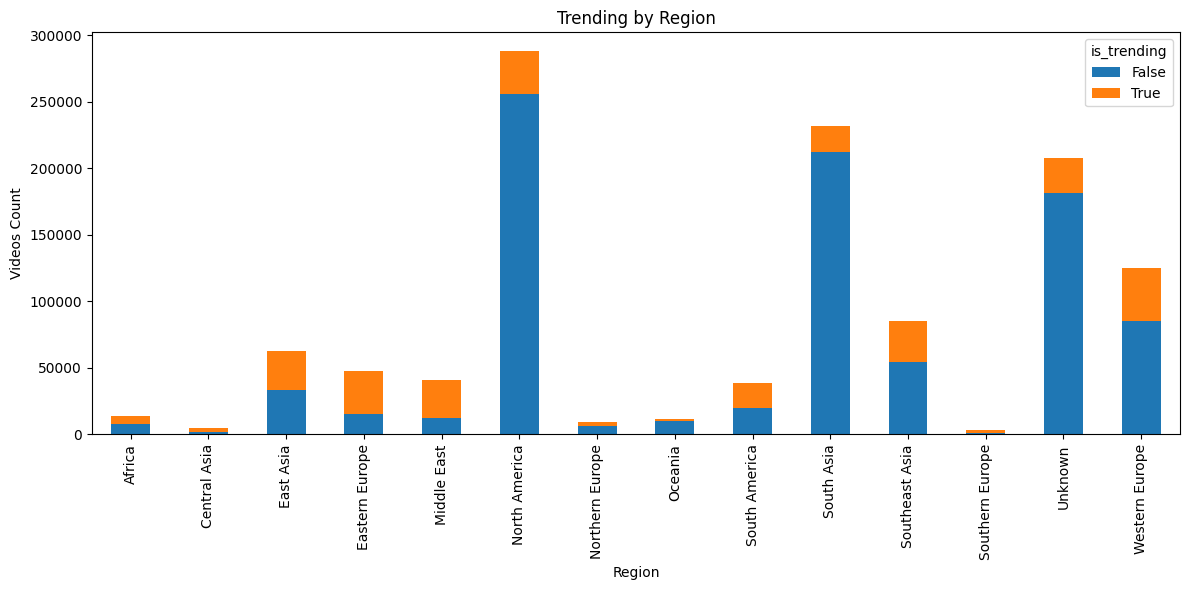

In [15]:
ct_region = pd.crosstab(df_video["country_region"], df_video["is_trending"])
ax = ct_region.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set_xlabel("Region")
ax.set_ylabel("Videos Count")
ax.set_title("Trending by Region")
ax.legend(title="is_trending")
plt.tight_layout()
plt.show()

In [16]:
print("\n=== Trending by Category ===")
print(pd.crosstab(df_video["category_id"], df_video["is_trending"]))


=== Trending by Category ===
is_trending   False   True 
category_id                
1             22681    2494
2              2005     199
10            74577   67947
15             7350      62
17            42136     746
19            17432     126
20           168564  168279
22           279939   19104
23            16129     812
24           115416   12487
25             4748     269
26            31048     181
27            88570     261
28            26341     339
29              784      82


## 8. EDA: Upload Patterns (Publish Time)

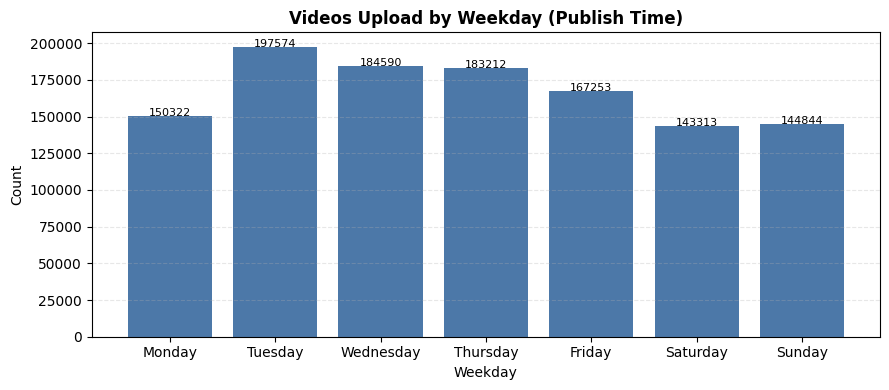

In [17]:
df_video["publish_weekday"] = df_video["publish_time"].dt.day_name()
df_video["publish_hour"] = df_video["publish_time"].dt.hour

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
upload_weekday = df_video["publish_weekday"].value_counts().reindex(weekday_order)

plt.figure(figsize=(9, 4))
bars = plt.bar(upload_weekday.index, upload_weekday.values, color="#4C78A8")
plt.title("Videos Upload by Weekday (Publish Time)", fontsize=12, weight="bold")
plt.xlabel("Weekday")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    if pd.notna(height):
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{int(height)}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

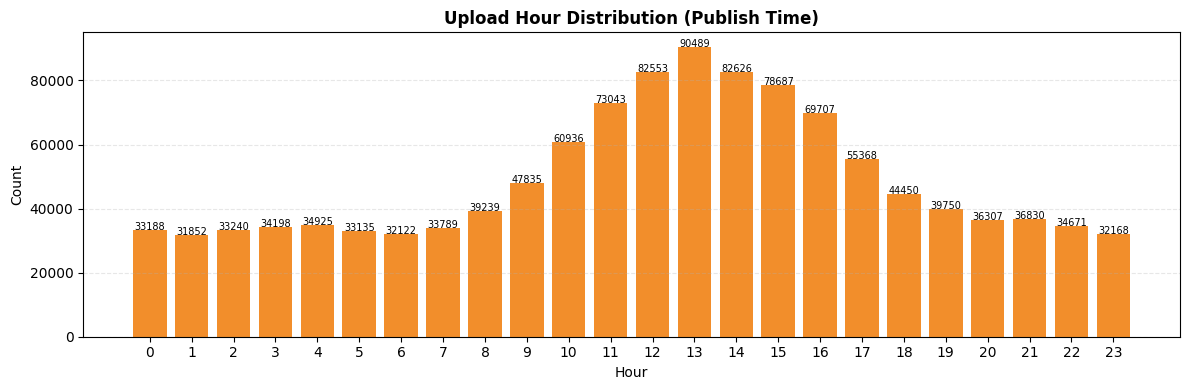

In [18]:
upload_hour = df_video["publish_hour"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
bars = plt.bar(upload_hour.index, upload_hour.values, color="#F28E2B")
plt.title("Upload Hour Distribution (Publish Time)", fontsize=12, weight="bold")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(range(24))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    if pd.notna(height):
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{int(height)}", ha="center", fontsize=7)

plt.tight_layout()
plt.show()

## 9. EDA: Trending Patterns (by Snapshot Time)

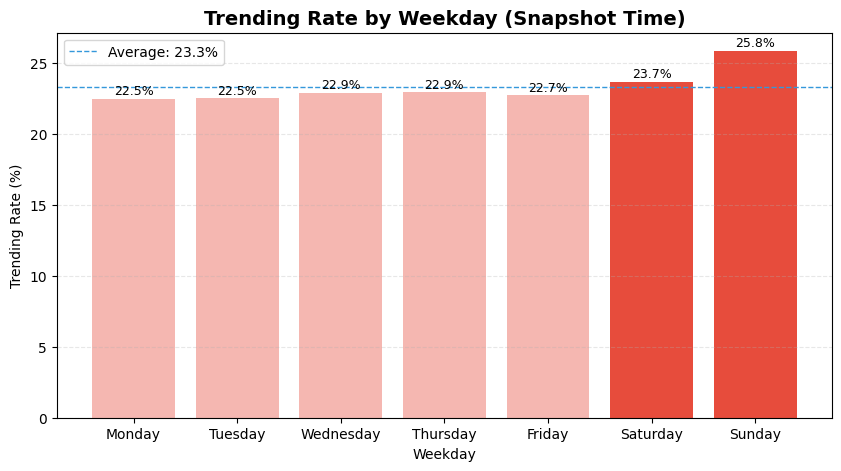

In [19]:
df_video["snapshot_weekday"] = df_video["snapshot_time"].dt.day_name()
df_video["snapshot_weekday"] = pd.Categorical(
    df_video["snapshot_weekday"],
    categories=weekday_order,
    ordered=True
)

ct_weekday = (
    pd.crosstab(df_video["snapshot_weekday"], df_video["is_trending"], normalize="index") * 100
).reindex(weekday_order)

trending_rate = ct_weekday[True]
avg_rate = trending_rate.mean()

colors = ["#E74C3C" if x >= avg_rate else "#F5B7B1" for x in trending_rate]

plt.figure(figsize=(10, 5))
bars = plt.bar(trending_rate.index, trending_rate.values, color=colors)

for bar in bars:
    height = bar.get_height()
    if pd.notna(height):
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.3, f"{height:.1f}%", ha="center", fontsize=9)

plt.axhline(avg_rate, color="#3498DB", linestyle="--", linewidth=1, label=f"Average: {avg_rate:.1f}%")
plt.title("Trending Rate by Weekday (Snapshot Time)", fontsize=14, weight="bold")
plt.xlabel("Weekday")
plt.ylabel("Trending Rate (%)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()
plt.show()

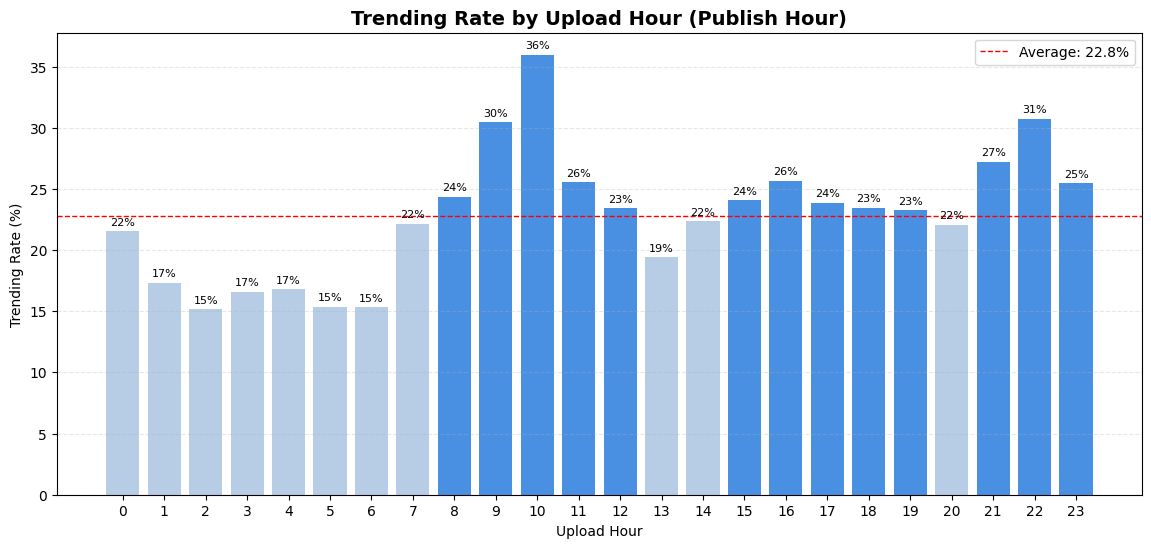

In [20]:
ct_hour = (df_video.groupby("publish_hour")["is_trending"].mean() * 100)
avg_rate = ct_hour.mean()

colors = ["#4A90E2" if x >= avg_rate else "#B7CDE5" for x in ct_hour]

plt.figure(figsize=(14, 6))
bars = plt.bar(ct_hour.index, ct_hour.values, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{height:.0f}%", ha="center", fontsize=8)

plt.axhline(avg_rate, color="red", linestyle="--", linewidth=1, label=f"Average: {avg_rate:.1f}%")
plt.title("Trending Rate by Upload Hour (Publish Hour)", fontsize=14, weight="bold")
plt.xlabel("Upload Hour")
plt.ylabel("Trending Rate (%)")
plt.xticks(range(24))
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

## 10. EDA: Engagement Metrics

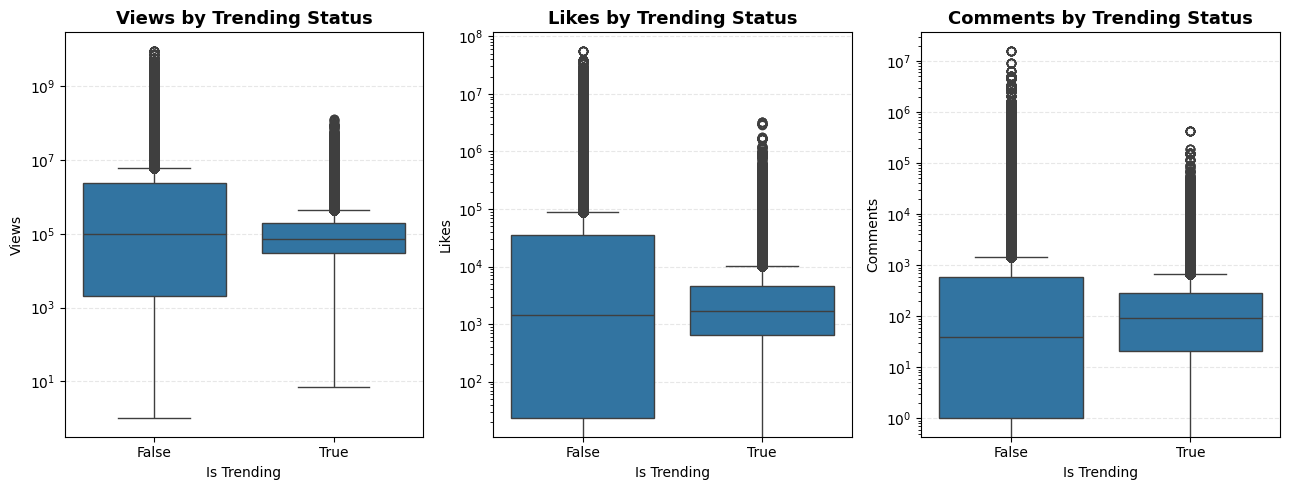

In [21]:
metrics = [
    ("views", "Views"),
    ("likes", "Likes"),
    ("comments", "Comments")
]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, (col, title) in zip(axes, metrics):
    sns.boxplot(data=df_video, x="is_trending", y=col, ax=ax)
    ax.set_yscale("log")
    ax.set_title(f"{title} by Trending Status", fontsize=13, weight="bold")
    ax.set_xlabel("Is Trending")
    ax.set_ylabel(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

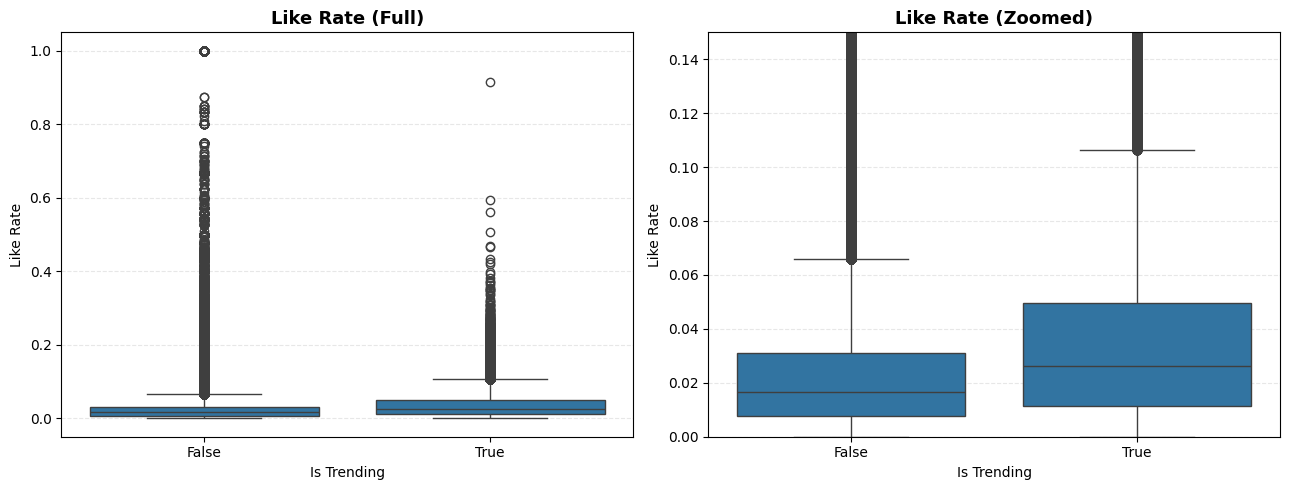

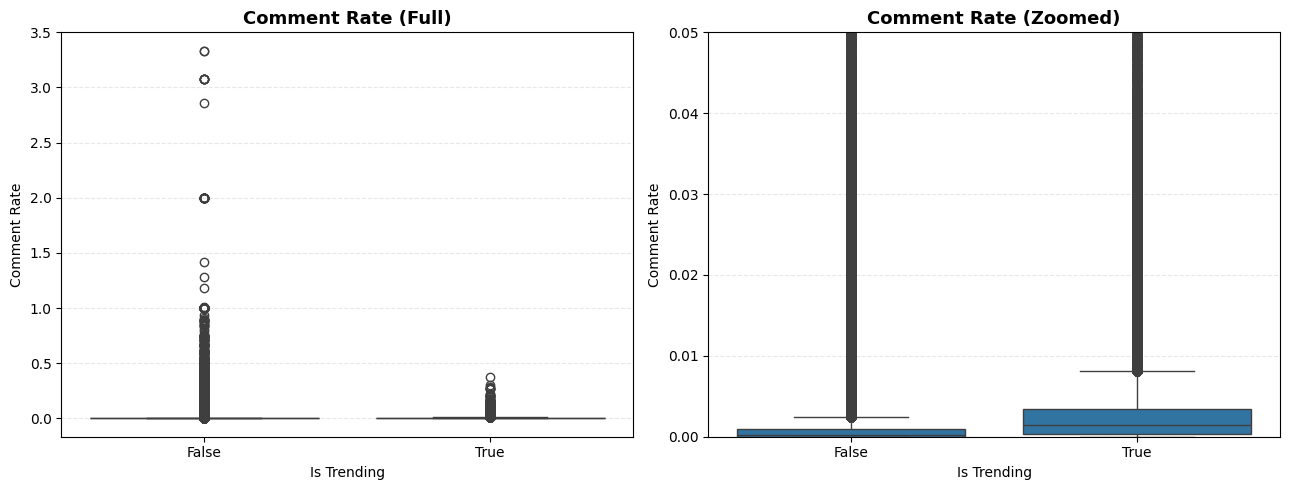

Trending videos have higher engagement rates than non-trending videos.


In [22]:
metrics = [
    ("like_rate", "Like Rate", 0.15),
    ("comment_rate", "Comment Rate", 0.05)
]

for col, title, y_limit in metrics:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Full data
    sns.boxplot(data=df_video, x="is_trending", y=col, ax=axes[0])
    axes[0].set_title(f"{title} (Full)", fontsize=13, weight="bold")
    axes[0].set_xlabel("Is Trending")
    axes[0].set_ylabel(title)
    axes[0].grid(axis="y", linestyle="--", alpha=0.3)

    # Zoomed
    sns.boxplot(data=df_video, x="is_trending", y=col, ax=axes[1])
    axes[1].set_ylim(0, y_limit)
    axes[1].set_title(f"{title} (Zoomed)", fontsize=13, weight="bold")
    axes[1].set_xlabel("Is Trending")
    axes[1].set_ylabel(title)
    axes[1].grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Trending videos have higher engagement rates than non-trending videos.")

## 11. Topic Analysis


In [23]:
print("\n=== Top Topics ===")
print(df_video["topic"].value_counts().head(10))

print("\n=== Trending Rate by Topic ===")
print(
    (
        df_video.groupby("topic")["is_trending"]
        .mean()
        .sort_values(ascending=False) * 100
    ).head(10)
)


=== Top Topics ===
topic
gaming           357332
music            180146
entertainment    152345
education         93016
vlog              64490
food              54775
fitness           49332
sports            43473
technology        30633
travel            25582
Name: count, dtype: int64

=== Trending Rate by Topic ===
topic
howto        100.000000
news         100.000000
cars         100.000000
comedy       100.000000
film         100.000000
science      100.000000
pets         100.000000
people       100.000000
nonprofit    100.000000
gaming        47.093179
Name: is_trending, dtype: float64


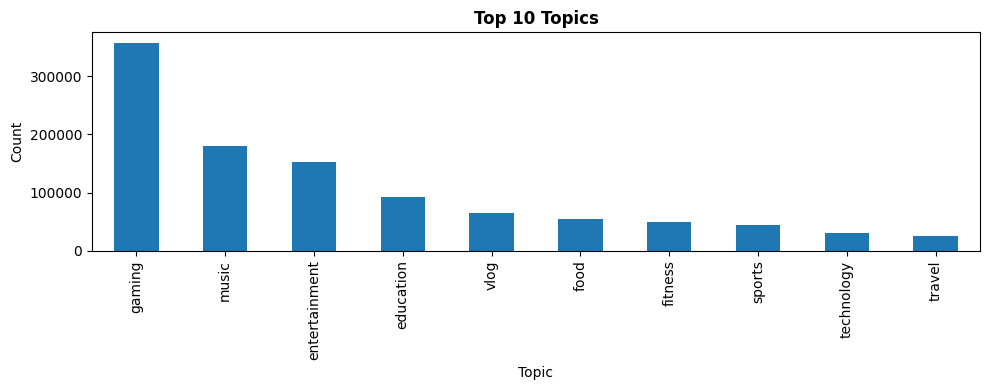

In [24]:
df_video["topic"].value_counts().head(10).plot(kind="bar", figsize=(10, 4))
plt.title("Top 10 Topics", fontsize=12, weight="bold")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 12. Channel Analysis


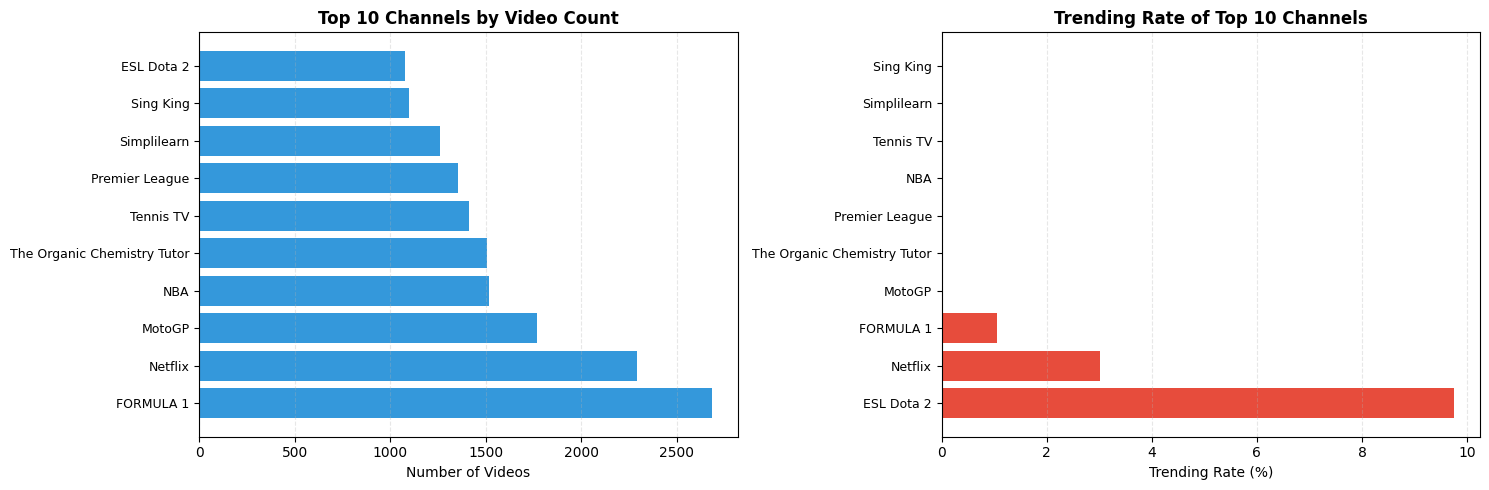

In [25]:
top_channels_data = df_video["channel_id"].value_counts().head(10)

# Map channel_id to channel_title
channel_names = df_video.drop_duplicates("channel_id")[["channel_id", "channel_title"]].set_index("channel_id")
channel_titles = [channel_names.loc[ch, "channel_title"] for ch in top_channels_data.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Videos per channel
ax1.barh(range(len(top_channels_data)), top_channels_data.values, color="#3498DB")
ax1.set_yticks(range(len(top_channels_data)))
ax1.set_yticklabels(channel_titles, fontsize=9)
ax1.set_xlabel("Number of Videos")
ax1.set_title("Top 10 Channels by Video Count", fontsize=12, weight="bold")
ax1.grid(axis="x", linestyle="--", alpha=0.3)

# Trending rate for top channels
top_ch_trending = df_video[df_video["channel_id"].isin(top_channels_data.index)].groupby("channel_id")["is_trending"].mean().sort_values(ascending=False)
top_ch_titles = [channel_names.loc[ch, "channel_title"] for ch in top_ch_trending.index]
ax2.barh(range(len(top_ch_trending)), top_ch_trending.values * 100, color="#E74C3C")
ax2.set_yticks(range(len(top_ch_trending)))
ax2.set_yticklabels(top_ch_titles, fontsize=9)
ax2.set_xlabel("Trending Rate (%)")
ax2.set_title("Trending Rate of Top 10 Channels", fontsize=12, weight="bold")
ax2.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


In [26]:
print("\n=== Top Channels ===")
top_channels_by_count = df_video["channel_id"].value_counts().head(10)
# Map channel_id to channel_title
channel_names = df_video.drop_duplicates("channel_id")[["channel_id", "channel_title"]].set_index("channel_id")
top_channels_info = top_channels_by_count.to_frame("count")
top_channels_info["channel_title"] = top_channels_info.index.map(lambda x: channel_names.loc[x, "channel_title"])
print(top_channels_info)

print("\n=== Trending Rate by Top Channels ===")
top_channels = df_video["channel_id"].value_counts().head(10).index
trending_by_ch = df_video[df_video["channel_id"].isin(top_channels)].groupby("channel_id")["is_trending"].agg(["sum", "count", "mean"]).sort_values("mean", ascending=False)
trending_by_ch["channel_title"] = trending_by_ch.index.map(lambda x: channel_names.loc[x, "channel_title"])
print(trending_by_ch)



=== Top Channels ===
                          count                channel_title
channel_id                                                  
UCB_qr75-ydFVKSF9Dmo6izg   2684                    FORMULA 1
UCWOA1ZGywLbqmigxE4Qlvuw   2291                      Netflix
UC8pYaQzbBBXg9GIOHRvTmDQ   1769                       MotoGP
UCWJ2lWNubArHWmf3FIHbfcQ   1517                          NBA
UCEWpbFLzoYGPfuWUMFPSaoA   1508  The Organic Chemistry Tutor
UCbcxFkd6B9xUU54InHv4Tig   1414                    Tennis TV
UCG5qGWdu8nIRZqJ_GgDwQ-w   1354               Premier League
UCsvqVGtbbyHaMoevxPAq9Fg   1259                  Simplilearn
UCwTRjvjVge51X-ILJ4i22ew   1098                    Sing King
UCaYLBJfw6d8XqmNlL204lNg   1076                   ESL Dota 2

=== Trending Rate by Top Channels ===
                          sum  count      mean                channel_title
channel_id                                                                 
UCaYLBJfw6d8XqmNlL204lNg  105   1076  0.097584         

In [27]:
df_video

,video_id,views,likes,comments,snapshot_time,is_trending,channel_id,time_id,source,title,description,publish_time,thumbnail,keyword,topic,duration_seconds,definition,caption,licensed_content,category_id,default_language,default_audio_language,tags,channel_title,custom_url,channel_description,channel_created_at,country,subscriber_count,view_count,video_count,date,year,quarter,month,week_of_year,day,weekday,hour,country_region,like_rate,comment_rate,publish_weekday,publish_hour,snapshot_weekday
0,atJwRQ1zdjQ,350781,35288,2980,2026-05-13 06:46:25.134504+00:00,True,UCUs8sGiP4avNaYNVO22INhQ,2026051216,trending,mgk & Wiz Khalifa - girl next door (Official M...,Watch the official music video for mgk & @wizk...,2026-05-12 16:00:06+00:00,https://i.ytimg.com/vi/atJwRQ1zdjQ/default.jpg,trending,music,237,hd,False,False,10,en,Unknown,"mgk,wiz khalifa,girl next door,blog era boyz,b...",mgk,@mgk,Unknown,2006-12-27T05:10:50Z,US,9470000,6778467533,390,2026-05-12,2026,2,5,20,12,1,16,North America,0.100598,0.008495,Tuesday,16,Wednesday
1,CnmcXIdMZ2Q,3244,54,4,2026-05-13 06:46:25.134504+00:00,False,UC-ik3qPQU2SQyzzAY5f_v7g,2026051301,search,"GILA! Veda Ega Pratama Bikin Dunia Shock, Indo...",Veda Ega Pratama kembali bikin dunia balap geg...,2026-05-13 01:19:00+00:00,https://i.ytimg.com/vi/CnmcXIdMZ2Q/default.jpg,motogp highlights,sports,29,hd,False,False,17,id,id,"veda ega pratama,\nveda ega moto3,\nmoto3 2026...",GLORA MOTOR,@gloramotor-k3,selamat datang di channel yang membahas panasn...,2025-11-15T14:50:48.636622Z,Unknown,1130,1262324,134,2026-05-13,2026,2,5,20,13,2,1,Southeast Asia,0.016646,0.001233,Wednesday,1,Wednesday
2,fNEGWXFmZcU,1709706,38087,1247,2026-05-13 06:46:25.134504+00:00,False,UCB_qr75-ydFVKSF9Dmo6izg,2026031306,search,FP1 Highlights | 2026 Chinese Grand Prix,Catch up on all the highlights from the sole p...,2026-03-13 06:01:00+00:00,https://i.ytimg.com/vi/fNEGWXFmZcU/default.jpg,formula 1 highlights,sports,300,hd,False,True,17,en,en,"F1,Formula One,Formula 1,Sports,Sport,Action,G...",FORMULA 1,@formula1,2026 - It's All To Drive For\n,2005-12-29T00:34:38Z,Unknown,14600000,9663626695,10069,2026-03-13,2026,1,3,11,13,4,6,Unknown,0.022277,0.000729,Friday,6,Wednesday
3,jL56ArZGc14,902,8,0,2026-05-13 06:46:25.134504+00:00,False,UChJQ9QWkZX28Rb8UwbD3vqg,2026031408,search,2026 China Grand Prix I Sprint Race Highlights...,Sprint Highlights | 2026 Chinese Grand Prix Ke...,2026-03-14 08:47:57+00:00,https://i.ytimg.com/vi/jL56ArZGc14/default.jpg,formula 1 highlights,sports,35,hd,False,False,2,en,Unknown,"#f1,#formula1,#f1sprint",MotoGenic,@motogenicrr,I created this channel to upload good quality ...,2011-10-12T07:38:31Z,Unknown,161,166307,133,2026-03-14,2026,1,3,11,14,5,8,Unknown,0.008869,0.000000,Saturday,8,Wednesday
4,ENqY3GeF1TM,11890,314,2,2026-05-13 06:46:25.134504+00:00,False,UCGtU-xV4vCM9bFoOwI16q9A,2026031409,search,Alonso 2026 highlights - F1 2026 | #f1 #alonso...,charlesleclerc #maxverstappen #alonso #lewisha...,2026-03-14 09:00:29+00:00,https://i.ytimg.com/vi/ENqY3GeF1TM/default.jpg,formula 1 highlights,sports,11,hd,False,False,17,it,en-US,Unknown,Daliots Sport,@liotts-sport,🏎️⚽ Benvenuti nel canale sport di Daliots!\n\n...,2024-12-21T15:54:51.992711Z,IT,1580,3197998,69,2026-03-14,2026,1,3,11,14,5,9,Western Europe,0.026409,0.000168,Saturday,9,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180601,vNVCWW0Cbt0,78907,818,28,2026-05-24 13:43:12.320594+00:00,True,UC9-yZkJfxtg6WNCX5mUQb0w,2026051409,trending,【ドラクエウォーク】ヘルガイオンの弱点とソロ安定攻略法！この構成でセミオートで楽勝です！,ヘルガイオンのオート攻略法を紹介！\n---------------------------...,2026-05-14 09:03:01+00:00,https://i.ytimg.com/vi/vNVCWW0Cbt0/default.jpg,trending,gaming,798,hd,False,True,20,ja,ja,"ドラクエウォーク,ドラクエ,DQウォーク,ドラゴンクエストウォーク,DQW,スマートウォーク...",ノゴローチャンネル,@nogoro_dq,ドラクエウォークのゲーム実況をしています！,2015-03-21T11:00:35Z,JP,129000,197872459,3885,2026-05-14,2026,2,5,20,14,3,9,East 

## 13. Export Cleaned Data


In [28]:
output_path = r"D:\KLTN\analysis\data\cleaned_video.csv"
df_video.to_csv(output_path, index=False)
print(f"Cleaned data exported to: {output_path}")
print(f"Shape: {df_video.shape}")
print(f"Unique videos: {df_video['video_id'].nunique()}")
print(f"Columns: {list(df_video.columns)}")


Cleaned data exported to: D:\KLTN\analysis\data\cleaned_video.csv
Shape: (1171108, 45)
Unique videos: 158073
Columns: ['video_id', 'views', 'likes', 'comments', 'snapshot_time', 'is_trending', 'channel_id', 'time_id', 'source', 'title', 'description', 'publish_time', 'thumbnail', 'keyword', 'topic', 'duration_seconds', 'definition', 'caption', 'licensed_content', 'category_id', 'default_language', 'default_audio_language', 'tags', 'channel_title', 'custom_url', 'channel_description', 'channel_created_at', 'country', 'subscriber_count', 'view_count', 'video_count', 'date', 'year', 'quarter', 'month', 'week_of_year', 'day', 'weekday', 'hour', 'country_region', 'like_rate', 'comment_rate', 'publish_weekday', 'publish_hour', 'snapshot_weekday']
